#Asignatura - IS-701-Inteligencia Artificial- Campus Comayagua Actividad en clase: Riesgo actuarial con K-means y Maquinas de Vectores de Soporte

Proposito didactico: practicar segmentacion no supervisada con K-means

* models/kmeasn_riesgo_actuarial.pk1
* models/svm_riesgo_actuarial.pk1
* models/model_metadata.json
* outputs/insurance_con_clusters.csv
* outputs/svbm

In [3]:
from logging import warning
from pathlib import Path
import json, joblib, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, classification_report, accuracy_score, ConfusionMatrixDisplay, precision_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

In [4]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
#Copia de trabajo
df_model=df.copy()

In [7]:
#Normalizar textos por seguridad
for col in ['sex', 'smoker', 'region']:
    df_model[col] = df_model[col].astype(str).str.strip().str.lower()

In [8]:
#Eliminar duplicados si existen
duplicados = df_model.duplicated().sum()
df_model = df_model.drop_duplicates()

In [9]:
print("Duplicaods eliminados:",duplicados)
print("Dimensiones despues de limpieza:",df_model.shape)

Duplicaods eliminados: 1
Dimensiones despues de limpieza: (1337, 7)


In [10]:
df_model.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


-- Analiasis exploratorio con Seaborn


Text(0.5, 1.0, 'Cargos por region y sexo')

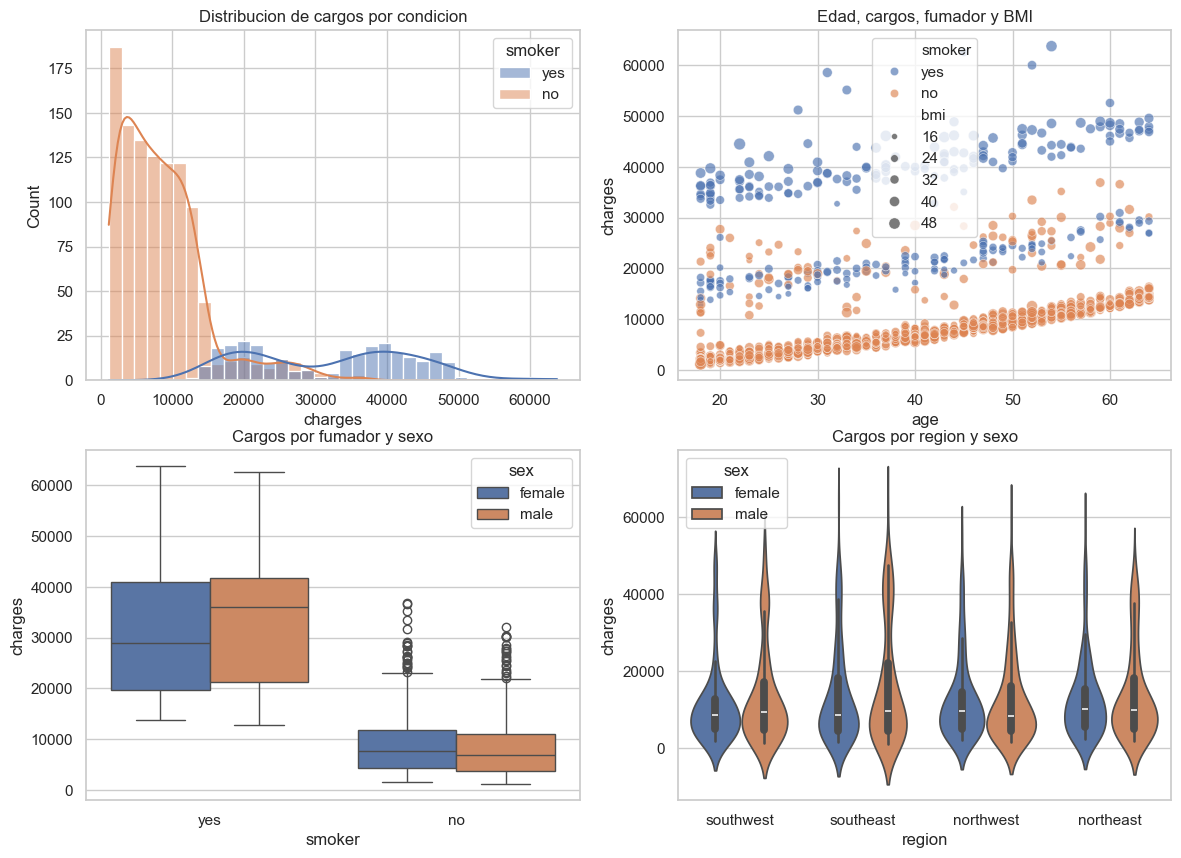

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df_model, x='age', y='charges', hue='smoker', size="bmi", alpha=.65, ax=axes[0,1])
axes[0,1].set_title("Edad, cargos, fumador y BMI")

sns.histplot(data=df_model, x='charges', hue='smoker', kde=True, bins=35, ax=axes[0,0])
axes[0,0].set_title("Distribucion de cargos por condicion")

sns.boxplot(data=df_model, x='smoker', y='charges', hue='sex', ax=axes[1,0])
axes[1,0].set_title("Cargos por fumador y sexo")

sns.violinplot(data=df_model, x='region', y='charges', hue='sex', ax=axes[1,1])
axes[1,1].set_title("Cargos por region y sexo")

5 Selección de cluster, identificación de variables
Para este ejemplo se usan variables numericas y categoricas
-Numericas: age, bmi, children, charges
-Categoricas: sex, smoker, region
Aqui utilizamos StandarScaler para normalizar variables numericoas y OneHotEncoder para convertir categorrías en variables binarias

In [12]:
numeric_features = ['age', 'bmi', 'children', 'charges']
categorical_features = ['sex', 'smoker', 'region']
X=df_model[numeric_features + categorical_features].copy()


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
(
        'num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

In [14]:
X_prepared = preprocessor.fit_transform(X)


In [15]:
print("Matriz preparada para K-means:", X_prepared.shape)

Matriz preparada para K-means: (1337, 12)


## 6. Selccion de número de clusters
Se evalúan varios valores de K mediante: 
1. Método del codo: Observa la reduccion de inercia
La invercia mide qué tan cerca están los datos de su centroide
En términos simples:
- Invercia baja = grupos compactos
- Invercia alta = grupos dispersos
2. Silhoutter score: mide qué tan separados de cohesiones están los clusters
mide la calidad de clusters:


Responde dos preguntas:

¿Los resultados están bien agrupados con los miembros de su propio cluster? ¿Están suficientemen alejados de otros clusters?

Interpretación


El resultado va de : 

1 a 1

- Valor de interpretación


## 7. Evaular el metodo del codo y el Silhuette Score

In [16]:
k_values = range(2, 9)
resultados_k = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    # K-Means se ejecutará 10 veces con centroides iniciales diferentes
    labels = km.fit_predict(X_prepared)
    resultados_k.append([
        k,
        km.inertia_,
        silhouette_score(X_prepared, labels)
    ])

resultados_k = pd.DataFrame(
    resultados_k,
    columns=["k", "inercia", "silhouette"]
)

display(resultados_k)

,k,inercia,silhouette
0,2,6139.034274,0.237855
1,3,5193.477059,0.178036
2,4,4470.136846,0.198088
3,5,4083.918576,0.183615
4,6,3843.347113,0.159733
5,7,3647.629957,0.157472
6,8,3481.686737,0.153093


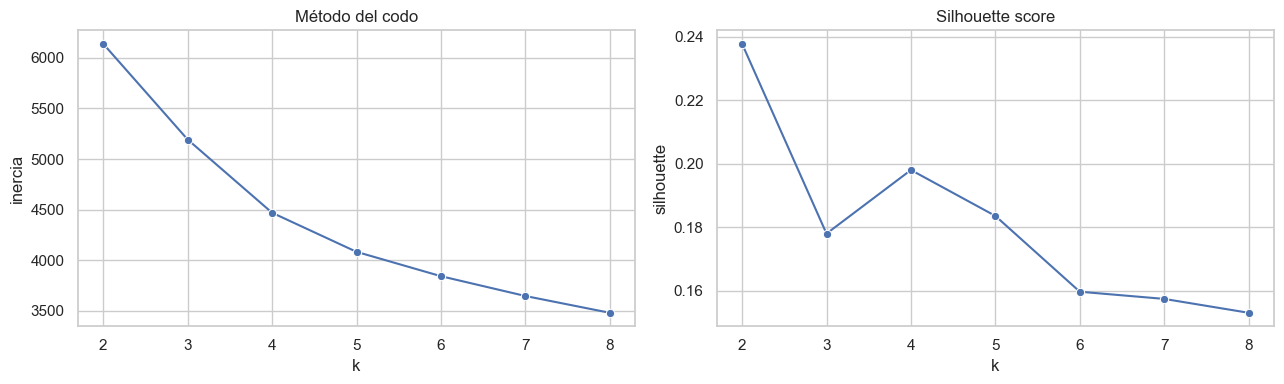

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(
    data=resultados_k,
    x="k",
    y="inercia",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Método del codo")

sns.lineplot(
    data=resultados_k,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Silhouette score")

plt.tight_layout()
plt.show()

## -8 Comenzar el entrenamiento 


Para nuestra clase de IA utilizaran 5 clusters, interpretados posteriormente como:

- Riesgo bajo
- Riesgo Medio 
- Riesgo Alto
La etiqueta final no viene en los datos: se asigna según el promdio de cargos médicos

In [18]:
K_FINAL = 3

kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=42,
    n_init=10
)

modelo_completo = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("kmeans", kmeans)
])

clusters = modelo_completo.fit_predict(X)

df_model["cluster"] = clusters

score_final = silhouette_score(
    modelo_completo.named_steps["preprocessor"].transform(X),
    clusters
)

print("Silhouette score final:", round(score_final, 4))

df_model.head()

Silhouette score final: 0.178


,age,sex,bmi,children,smoker,region,charges,cluster
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,1
2,28,male,33.000,3,no,southeast,4449.46200,1
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,1


## 9. Interpretación de los clusters

Ahora se calculan las estadicisticas por clusters:

La interpretación de riesgo se basará principalmente en :
- Promedio de cagos médicos
- Porcetnaje de fumadores
- Edad promedio
- BMI promedio 

Luego se ordenan los clusters de menor a mayor según el riesgo y charges promedio

In [19]:
# Resumen numérico por cluster
resumen_clusters = df_model.groupby("cluster").agg(
    cantidad_clientes=("cluster", "count"),
    edad_promedio=("age", "mean"),
    bmi_promedio=("bmi", "mean"),
    hijos_promedio=("children", "mean"),
    cargos_promedio=("charges", "mean"),
    cargos_mediana=("charges", "median"),
    cargos_maximos=("charges", "max"),
    porcentaje_fumadores=("smoker", lambda x: (x == "yes").mean() * 100)
).round(2)

display(resumen_clusters)

,cantidad_clientes,edad_promedio,bmi_promedio,hijos_promedio,cargos_promedio,cargos_mediana,cargos_maximos,porcentaje_fumadores
cluster,,,,,,,,
0,234,41.62,32.01,1.19,35148.37,36708.87,63770.43,97.01
1,564,27.14,28.43,0.98,5985.61,4241.74,27375.90,8.33
2,539,50.83,32.41,1.18,11416.66,10594.50,31620.00,0.00


In [20]:
# Asignar nivel de riesgo según cargos promedio
orden_riesgo = resumen_clusters.sort_values("cargos_promedio").index.tolist()

mapa_riesgo = {
    orden_riesgo[0]: "Bajo",
    orden_riesgo[1]: "Medio",
    orden_riesgo[2]: "Alto"
}

df_model["riesgo_actuarial"] = df_model["cluster"].map(mapa_riesgo)

print("Mapa de riesgo por cluster:")
display(pd.DataFrame({
    "cluster": list(mapa_riesgo.keys()),
    "riesgo_actuarial": list(mapa_riesgo.values())
}))

display(df_model[["age", "sex", "bmi", "children", "smoker", "region", "charges", "cluster", "riesgo_actuarial"]].head())

Mapa de riesgo por cluster:


,cluster,riesgo_actuarial
0,1,Bajo
1,2,Medio
2,0,Alto


,age,sex,bmi,children,smoker,region,charges,cluster,riesgo_actuarial
0,19,female,27.900,0,yes,southwest,16884.92400,1,Bajo
1,18,male,33.770,1,no,southeast,1725.55230,1,Bajo
2,28,male,33.000,3,no,southeast,4449.46200,1,Bajo
3,33,male,22.705,0,no,northwest,21984.47061,1,Bajo
4,32,male,28.880,0,no,northwest,3866.85520,1,Bajo


## 10. Visualización de clusters con PCA
Como el modelo usa variables, reducimos a 2 dimensiones con PCA, solo para visualizar PCA no reemplaza el modelo, es una ventana para mirar un espacio más grande en ua hoja más grande

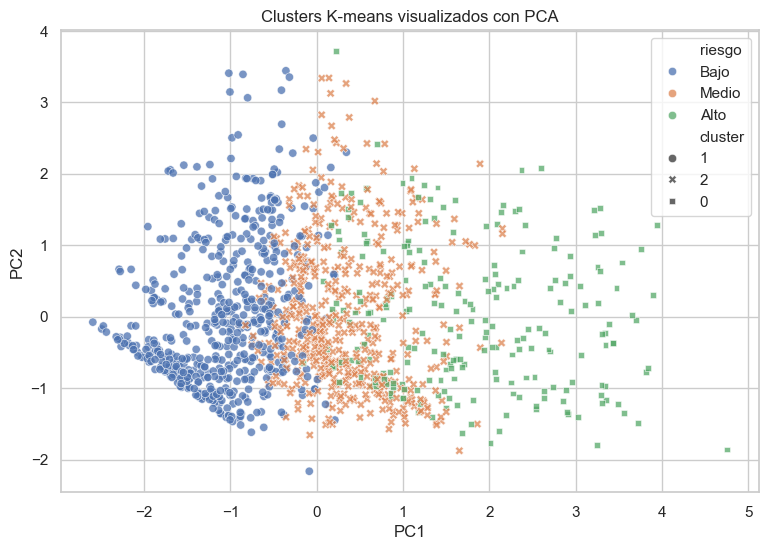

Varianza explicada por PCA: [0.2714 0.1788]


In [21]:
X_transformado = modelo_completo.named_steps["preprocessor"].transform(X)
X_denso = X_transformado.toarray() if hasattr(X_transformado, "toarray") else X_transformado

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_denso)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = df_model["cluster"].astype(str).values
df_pca["riesgo"] = df_model["riesgo_actuarial"].values

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="riesgo", style="cluster", alpha=.75)
plt.title("Clusters K-means visualizados con PCA")
plt.show()

print("Varianza explicada por PCA:", np.round(pca.explained_variance_ratio_, 4))

## 11. SVM para practicar sobre los grupos de riesgo
K-means crea los grupos sin etiqueta previa. Para practicar márquinas de vectores  de Soporte, se toma la equiqueta de riesgo generada por 

Kmeans y se entrena un clasificador SVM

Esto permite comparar fronteras de decisioón por kenernel lineal, poly,rbf, sigmoid.

In [22]:
# Datos para SVM: se usa PCA 2D para visualizar fronteras de decisión en clase
X_svm = df_pca[["PC1", "PC2"]]
y_svm = df_model["riesgo_actuarial"]

X_train, X_test, y_train, y_test = train_test_split(
    X_svm, y_svm, test_size=0.30, random_state=RANDOM_STATE, stratify=y_svm
)

kernels = {
    "linear": {"kernel": "linear", "C": 1},
    "poly": {"kernel": "poly", "C": 1, "degree": 3, "gamma": "scale"},
    "rbf": {"kernel": "rbf", "C": 1, "gamma": "scale"},
    "sigmoid": {"kernel": "sigmoid", "C": 1, "gamma": "scale"}
}

svm_models, svm_results = {}, []

for name, params in kernels.items():
    svm = SVC(**params, random_state=RANDOM_STATE)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    svm_models[name] = svm
    svm_results.append({
        "kernel": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )
    })

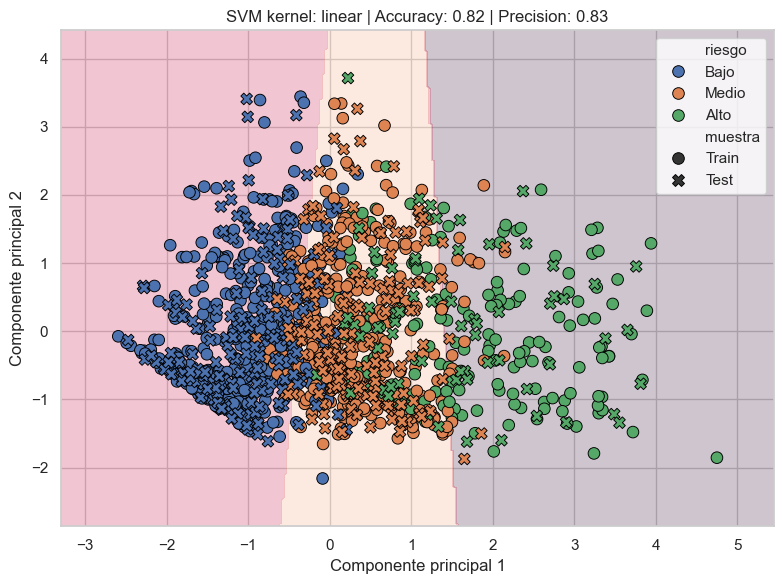

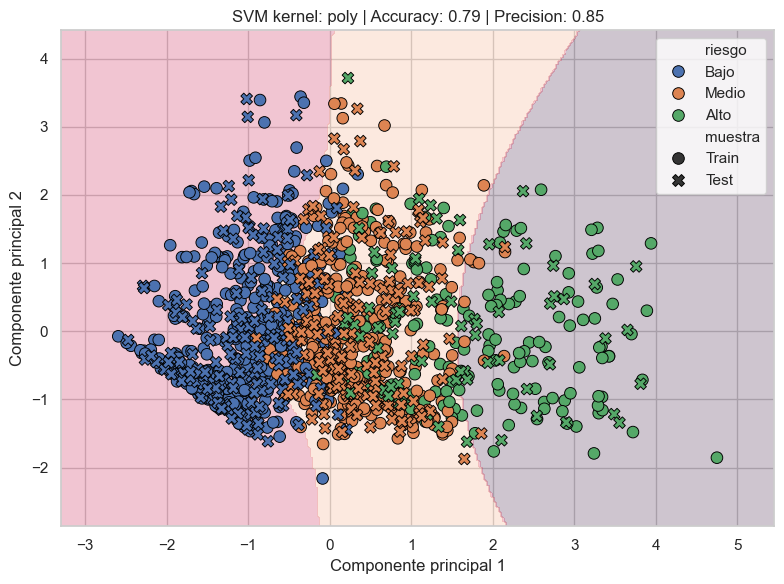

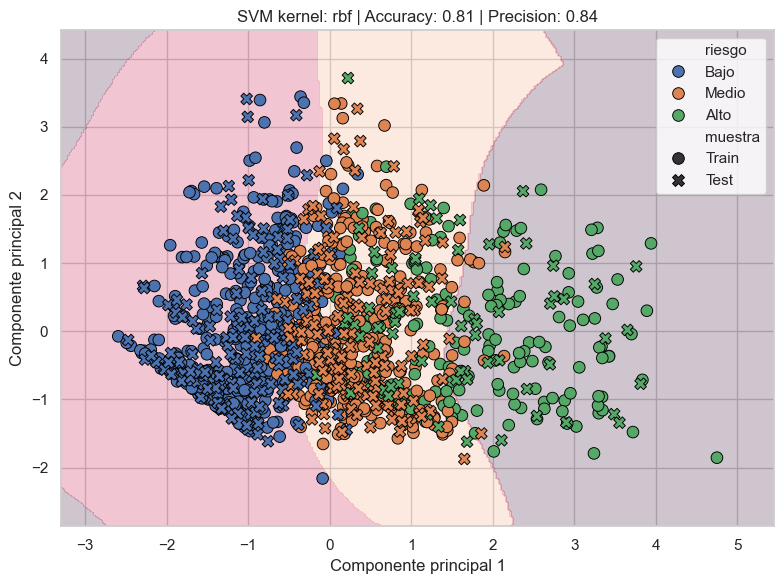

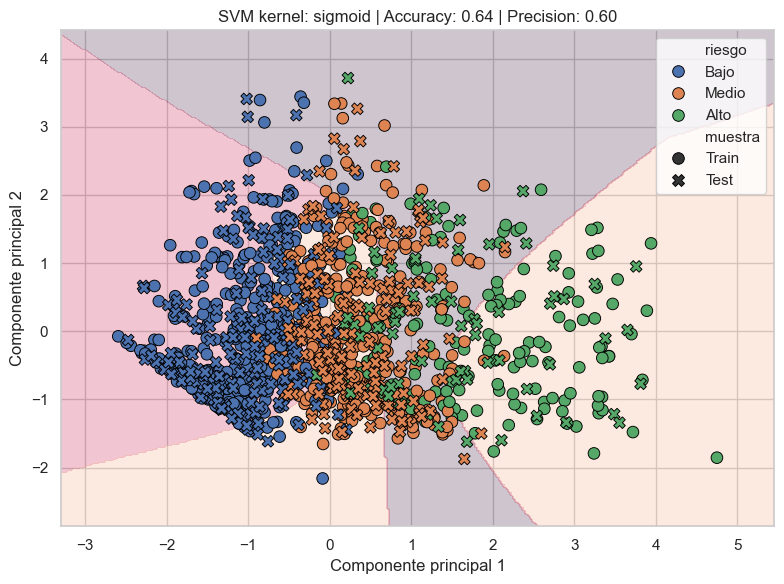

In [23]:
def graficar_frontera_svm(modelo, kernel, X_train, X_test, y_train, y_test):
    datos = pd.concat([
        X_train.assign(riesgo=y_train.values, muestra="Train"),
        X_test.assign(riesgo=y_test.values, muestra="Test")
    ])

    x_min, x_max = datos.PC1.min() - .7, datos.PC1.max() + .7
    y_min, y_max = datos.PC2.min() - .7, datos.PC2.max() + .7
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = modelo.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["PC1", "PC2"])).reshape(xx.shape)
    clases = list(modelo.classes_)
    Z_num = np.vectorize(clases.index)(Z)

    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="macro", zero_division=0)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z_num, alpha=.25, levels=np.arange(len(clases)+1)-.5)
    sns.scatterplot(data=datos, x="PC1", y="PC2", hue="riesgo", style="muestra", s=70, edgecolor="black")
    plt.title(f"SVM kernel: {kernel} | Accuracy: {acc:.2f} | Precision: {prec:.2f}")
    plt.xlabel("Componente principal 1")
    plt.ylabel("Componente principal 2")
    plt.tight_layout()
    plt.show()

for kernel, modelo in svm_models.items():
    graficar_frontera_svm(modelo, kernel, X_train, X_test, y_train, y_test)

## 12. Función para evaluar un cliente nuevo 

Esta función recibe los datos de un clientes y devuelve : 
- Cluster asignado
- Nivel de reisgo actuarial
- Explicación breve

In [24]:
def evaluar_cliente(age, sex, bmi, children, smoker, region, charges):
    cliente = pd.DataFrame([{
        "age": age,
        "sex": str(sex).lower(),
        "bmi": bmi,
        "children": children,
        "smoker": str(smoker).lower(),
        "region": str(region).lower(),
        "charges": charges
    }])

    cluster = int(modelo_completo.predict(cliente)[0])
    riesgo = mapa_riesgo[cluster]

    explicacion = {
        "Bajo": "Cliente agrupado con perfiles de menor costo médico promedio.",
        "Medio": "Cliente agrupado con perfiles de costo y factores de riesgo intermedios.",
        "Alto": "Cliente agrupado con perfiles de mayor costo médico promedio y/o factores de riesgo relevantes."
    }

    return {
        "cluster": cluster,
        "riesgo_actuarial": riesgo,
        "explicacion": explicacion[riesgo]
    }

# Ejemplo de uso
resultado = evaluar_cliente(
    age=45,
    sex="male",
    bmi=31.2,
    children=2,
    smoker="yes",
    region="southeast",
    charges=28000
)

resultado

{'cluster': 0,
 'riesgo_actuarial': 'Alto',
 'explicacion': 'Cliente agrupado con perfiles de mayor costo médico promedio y/o factores de riesgo relevantes.'}

## 13.Guardar salidas del Proyecto


In [25]:
# Crear carpetas locales junto al notebook
MODEL_DIR = Path("models")
OUTPUT_DIR = Path("outputs")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KMEANS_PATH = MODEL_DIR / "kmeans_riesgo_actuarial.pkl"
SVM_PATH = MODEL_DIR / "svm_riesgo_actuarial.pkl"
META_PATH = MODEL_DIR / "model_metadata.json"
CSV_CLUSTERS_PATH = OUTPUT_DIR / "insurance_con_clusters.csv"
SVM_RESULTS_PATH = OUTPUT_DIR / "svm_resultados_kernels.csv"

metadata = {
    "nombre_modelo": "K-means + SVM para riesgo actuarial",
    "tipo_modelo": "Clustering no supervisado + clasificación supervisada didáctica",
    "n_clusters": K_FINAL,
    "silhouette_score": round(float(score_final), 4),
    "variables_numericas": numeric_features,
    "variables_categoricas": categorical_features,
    "mapa_riesgo": {str(k): v for k, v in mapa_riesgo.items()},
    "svm_kernels": list(svm_models.keys()),
    "archivos_generados": [
        str(KMEANS_PATH), str(SVM_PATH), str(META_PATH),
        str(CSV_CLUSTERS_PATH), str(SVM_RESULTS_PATH)
    ]
}
joblib.dump(modelo_completo, KMEANS_PATH)
joblib.dump(svm_models, SVM_PATH)
df_model.to_csv(CSV_CLUSTERS_PATH, index=False)
svm_results_df = pd.DataFrame(svm_results)
svm_results_df.to_csv(SVM_RESULTS_PATH, index=False)

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Archivos guardados correctamente:")
for ruta in metadata["archivos_generados"]:
    print("-", ruta)

Archivos guardados correctamente:
- models\kmeans_riesgo_actuarial.pkl
- models\svm_riesgo_actuarial.pkl
- models\model_metadata.json
- outputs\insurance_con_clusters.csv
- outputs\svm_resultados_kernels.csv


## 14.Se guardan automáticamente los archivos

## 15. Código base para usar el modelo en streamlit 

Este fragmento muestra como cargar el modelo entrenado desde una app, app.py


import joblib
import pandas as pd

modelo = joblib.load("models/kmeans_riesgo_actuarial.pkl")

cliente = pd.DataFrame([{
    "age": 45,
    "sex": "male",
    "bmi": 31.2,
    "children": 2,
    "smoker": "yes",
    "region": "southeast",
    "charges": 28000
}])

cluster = modelo.predict(cliente)[0]